### **Final assignment: DQN** 

#### `MinAtar/SeaQuest`

In [ ]:
# Based mostly on cleanrl 
#   https://github.com/vwxyzjn/cleanrl/blob/master/cleanrl/dqn_atari.py 
#   https://github.com/vwxyzjn/cleanrl/blob/master/cleanrl/c51_atari.py
#   which in turn is also partly based on Stable Baselines 3 

# Partly inspired by MinAtar/examples/dqn.py as well, but not that much 
#   https://github.com/kenjyoung/MinAtar/blob/master/examples/dqn.py 
#   I generally preferred the structure of cleanrl 

# Using torch, gymnasium, minatar 

# SeaQuest:
# https://ale.farama.org/environments/seaquest/ 
# "Rewards. Score points are your only reward. 
#  Blasting enemy sub and killer shark is worth 20 points. 
#  Every time you surface with six divers, the value of enemy subs and killer sharks increases by 10, 
#  up to a maximum of 90 points each." 
# Rewards in MinAtar/SeaQuest: https://github.com/kenjyoung/MinAtar/tree/master

In [ ]:
# General
import random
from time import time
from dataclasses import dataclass 
from tqdm import tqdm
import os
os.environ["WANDB_NOTEBOOK_NAME"] = "Final assignment-DQN.ipynb"

# RL environment
import gymnasium as gym
from gymnasium.wrappers import (
    RecordEpisodeStatistics,
    FrameStackObservation,
    # GrayScaleObservation,
)
import minatar 
import minatar.gym
# import ale_py  # gymnasium Atari 

# Numerical stuff, deep learning
import numpy as np 
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import scipy

# Baseline-implementations of RL algorithms
import stable_baselines3 as sb3
from stable_baselines3.common.buffers import ReplayBuffer
# from stable_baselines3.common.atari_wrappers import (
#     ClipRewardEnv,
#     EpisodicLifeEnv,
#     MaxAndSkipEnv,
# )

# Tracking
from torch.utils.tensorboard import SummaryWriter
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import wandb

# Visualization
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import matplotlib.colors as colors
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
import seaborn as sns
import imageio
from IPython.display import Image
import umap

# Tables
import pandas as pd 

#### Configuration

In [ ]:
# Data class that contains all configurations needed for a run 

@dataclass
class Config:
    method: str = "dqn"
    seed: int = 0                            # random seed 
    
    # capture_video: bool = False             # 
    save_model: bool = False                 # whether to save model into the `runs/{run_name}` folder
    env_id: str = "MinAtar/Seaquest-v1"      # the id/name of the environment
    total_timesteps: int = 1_000_000         # total number of timesteps during training (param update not necessarily every timestep!)
    learning_rate: float = 1e-4              # the learning rate of the optimizer (default 1e-4)
    buffer_size: int = 50_000               # the replay memory buffer size (originally 1_000_000)
    gamma: float = 0.99                      # the discount factor gamma
    tau: float = 1.0                         # the target network update rate
    batch_size: int = 64                     # batch size from the replay memory
    epsilon_initial: float = 1               # initial epsilon (before decay) 
    epsilon_final: float = 0.01              # final epsilon 
    exploration_fraction: float = 0.1        # fraction of `total-timesteps` it takes from initial epsilon to go final epsilon
    learning_starts: int = 10_000            # timestep to start learning 
    train_frequency: int = 1                 # frequency of timesteps at which parameters are updated during training (default: 4)
    q_target_frequency: int = 200            # frequency of timesteps at which target network's parameters are updated during training (default: 1_000)
    cuda: bool = False                       # 
    total_eval_timesteps: int = 100_000      # total number of timesteps during evaluation 
    reward_clipping: bool = True             # whether to clip all negative rewards to -1, positive rewards to +1 
    frame_stacking: int = 1                  # how many past/present frames to stack into the current observation in total (default: 4)

    # Set when initialized
    timestamp: int = None 
    run_name: str = None

config = Config()  # default configuration 

In [ ]:
def linear_schedule(epsilon_initial: float, epsilon_final: float, duration: int, t: int):
    """
    Schedule hyperparameter linearly
    Returns value of hyperparameter at time t, given a start value, end value and duration 
    """
    slope = (epsilon_final - epsilon_initial) / duration
    return max(slope * t + epsilon_initial, epsilon_final)

#### Environment

In [ ]:
minatar.gym.register_envs()
# gym.register_envs(ale_py)

In [ ]:
def make_env(capture_video=False, **env_kwargs):
    """
    if capture_video:
        env = gym.make(config.env_id, render_mode="rgb_array")
        env = gym.wrappers.RecordVideo(env, f"videos/{run_name ???}")
    else:
    """
    env = gym.make(config.env_id, **env_kwargs)
    # Wrappers
    env = RecordEpisodeStatistics(env)
    # env = MaxAndSkipEnv(env, skip=4)
    # env = EpisodicLifeEnv(env)
    # env = ClipRewardEnv(env)
    # env = GrayScaleObservation(env)
    env = FrameStackObservation(env, config.frame_stacking)  # using global config!
    return env 

In [ ]:
# Meaning of channels and actions
# Source: https://github.com/kenjyoung/MinAtar/blob/master/minatar/environments/seaquest.py

# Observation channels
# 0: sub front
# 1: sub back
# 2: friendly bullet
# 3: trail
# 4: enemy bullet
# 5: enemy fish
# 6: enemy sub
# 7: oxygen gauge
# 8: diver gauge
# 9: diver

# Actions
# 0: noop
# 1: left
# 2: up
# 3: right
# 4: down
# 5: fire

action_map = [
    "noop",
    "left",
    "up",
    "right",
    "down",
    "fire"
]

#### Deep Q Network

In [ ]:
class DQN(nn.Module):
    """
    Deep Q Network (DQN) agent
    Convolutional layer to encode the input frames,
    flatten resulting feature map into a single vector,
    then two fully connected layers.
    Output one q-value per action.
    """
    def __init__(self, env, config):
        super().__init__()
        self.config = config
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=16, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten(),  # shape: (batch_size=32, n_features=1024) 
            nn.Linear(1024, 128),
            nn.ReLU(),
            nn.Linear(128, env.action_space.n),
        )
    def forward(self, x):
        """
        x has shape (32, 1, 10, 10, 10) 
        i.e. (b=32, f=1, h=10, w=10, c=10)
          where b: batch size, f: num frames, h: height, w: width, c: num channels
        First, I reshape this to (b, f, c, h, w),
        and then I stack the n_frames and n_channels dimensions 
        resulting in (32, 1*10, 10, 10)
        """
        x = x.float()
        x = x.permute(0, 1, 4, 2, 3)     # (b, f, c, h, w)
        x = x.reshape(-1, 10, 10, 10)    # (b, f*c, h, w) 
        return self.network(x)
    """
    def get_latent(self, x):
        x = x.float()
        x = x.permute(0, 1, 4, 2, 3)     # (b, f, c, h, w)
        x = x.reshape(-1, 1*10, 10, 10)  # (b, f*c, h, w) 
        return self.network[:5](x)
    """

#### Training

In [ ]:
%%time 

def train(config): 
    ## Initialization 

    config.timestamp = int(time()) 
    config.run_name = f"dqn__{config.env_id.replace('/', '-')}__{config.seed}__{config.timestamp}"

    # Environment
    env = make_env()
    
    # Seeding 
    random.seed(config.seed)
    torch.manual_seed(config.seed)
    np.random.seed(config.seed)
    env.action_space.seed(config.seed)
    
    # Tracking
    wandb.init(
        project="final-assignment",
        entity="jeuskir",
        sync_tensorboard=True,
        config=vars(config), 
        name=config.run_name, 
        monitor_gym=True,
        save_code=False,
        # resume=True
    )
    writer = SummaryWriter(f"runs/{config.run_name}")
    writer.add_text(
        "hyperparameters",
        "|param|value|\n|-|-|\n%s" % ("\n".join([f"|{key}|{value}|" for key, value in vars(config).items()])),
    )
    
    # Torch
    device = torch.device("cuda" if torch.cuda.is_available() and config.cuda else "cpu")
    
    # DQN stuff 
    q = DQN(env, config).to(device)  # main Q-network
    q_target = DQN(env, config).to(device)  # target Q-network
    q_target.load_state_dict(q.state_dict())
    optimizer = optim.Adam(q.parameters(), lr=config.learning_rate)
    buffer = ReplayBuffer(
        config.buffer_size,
        env.observation_space,
        env.action_space,
        device,
        optimize_memory_usage=True,
        handle_timeout_termination=False,
    )
    
    ## Training
    
    episode = 0
    start_time = time()
    
    obs, _ = env.reset(seed=config.seed)
    
    for global_step in tqdm(range(config.total_timesteps)):
        
        # Pick action (randomly with prob. epsilon, otherwise according to Q-network) 
        epsilon = linear_schedule(
            config.epsilon_initial, 
            config.epsilon_final, 
            config.exploration_fraction * config.total_timesteps, 
            global_step
        )
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            q_values = q(torch.tensor(obs).unsqueeze(0))
            action = torch.argmax(q_values, dim=1).cpu().item()
    
        # Perform environment step
        next_obs, reward, terminated, truncated, info = env.step(action)
        if config.reward_clipping:
            # Alternatively, use ClipRewardEnv wrapper 
            reward = np.clip(reward, -1, 1)
        
        # Special next observation in case episode is truncated 
        if truncated: 
            _next_obs = info["final_observation"] 
        else:
            _next_obs = next_obs.copy()
    
        # Save data to replay buffer
        # Somewhat annoyingly, buffer expects arrays, assuming multiple parallel envs, 
        # so I wrap each entry in a np.array: 
        buffer.add(
            np.array([obs]), 
            np.array([_next_obs]), 
            np.array([action]), 
            np.array([reward]), 
            np.array([terminated]), 
            np.array([info])
        )
    
        # Adopt next observation as new, current observation 
        if terminated or truncated:
            obs, _ = env.reset(seed=config.seed)
            episode += 1
            # Record return and episode length for plotting purposes
            if info and "episode" in info: 
                writer.add_scalar("train/episode_return", info["episode"]["r"], global_step)  # undiscounted return
                writer.add_scalar("train/episode_length", info["episode"]["l"], global_step) 
        else:
            obs = next_obs
    
        # Training
        if global_step == config.learning_starts:
            # print("Start training!")
            first_train_episode = episode
        if global_step > config.learning_starts:
            if global_step % config.train_frequency == 0:
                
                # Sample a batch of examples from replay buffer 
                batch = buffer.sample(config.batch_size)
                with torch.no_grad():
                    # target_max is 0 if the state is terminal 
                    q_max, _ = q(batch.next_observations).max(dim=1)  
                    target = batch.rewards.flatten() + config.gamma * q_max * (1-batch.dones.flatten())  
                    # TD target: r + γ * q_target(s', a'), 
                    # where a' = argmax_b q_target(s', b) and a' = argmax_b q(s', b) 
                pred = q(batch.observations).gather(1, batch.actions).squeeze()  # q(s, a)
                loss = F.mse_loss(pred, target)  # squared TD error 
                
                if global_step % 100 == 0:
                    writer.add_scalar("train/loss", loss, global_step)
                    writer.add_scalar("train/q_values", pred.mean().item(), global_step)
    
                # Parameter update 
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
    
            # Update target network
            if global_step % config.q_target_frequency == 0:
                for q_target_param, q_param in zip(q_target.parameters(), q.parameters()):
                    q_target_param.data.copy_(config.tau * q_param.data + (1.0-config.tau) * q_target_param.data)
    
    model_path = f"runs/{config.run_name}.torch"
    torch.save(q.state_dict(), model_path)
    print(f"model saved to {model_path}")
    print("Episode counter:", episode)

    env.close()
    writer.close()

    return q

q = train(
    # Change specific config values, depending on desired run 
    Config(
        seed=1,
    )
)

In [ ]:
def load_history(run_name, mode="train"):
    """
    mode should be either "train" or "eval"
    """
    history = EventAccumulator(f"runs/{run_name}") 
    history.Reload()
    # print(history.Tags())
    
    history_episode_return = history.Scalars(f"{mode}/episode_return")
    history_episode_length = history.Scalars(f"{mode}/episode_length")
    history_loss = history.Scalars(f"{mode}/loss")
    history_q_values = history.Scalars(f"{mode}/q_values") 
    
    # Turn into arrays
    arr_episode_return = np.array([[step.step, step.value] for step in history_episode_return])
    arr_episode_length = np.array([[step.step, step.value] for step in history_episode_length])
    arr_loss = np.array([[step.step, step.value] for step in history_loss])
    arr_q_values = np.array([[step.step, step.value] for step in history_q_values])
    
    return (
        arr_episode_return,
        arr_episode_length,
        arr_loss,
        arr_q_values
    )

In [31]:
def plot(arr_episode_return, arr_episode_length, arr_loss, arr_q_values):
    fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(15, 8))
    
    axes[0,0].set_title("Episode return")
    axes[0,0].set_ylabel("Return")
    axes[0,0].set_xlabel("Step")
    axes[0,0].axvline(config.learning_starts, color="grey", ls="--", alpha=0.2)
    axes[0,0].axvline(0, color="grey", alpha=0.2)
    axes[0,0].axhline(0, color="grey", alpha=0.2)
    axes[0,0].plot(arr_episode_return[:,0], arr_episode_return[:,1], color="green", alpha=0.3)
    axes[0,0].plot(arr_episode_return[:,0], pd.Series(arr_episode_return[:,1]).rolling(window=20).mean(), color="green", alpha=1.0)
    
    axes[0,1].set_title("Episode length")
    axes[0,1].set_ylabel("Episode length")
    axes[0,1].set_xlabel("Step")
    axes[0,1].axvline(config.learning_starts, color="grey", ls="--", alpha=0.2)
    axes[0,1].axvline(0, color="grey", alpha=0.2)
    axes[0,1].axhline(0, color="grey", alpha=0.2)
    axes[0,1].plot(arr_episode_length[:,0], arr_episode_length[:,1], color="orange", alpha=0.3)
    axes[0,1].plot(arr_episode_length[:,0], pd.Series(arr_episode_length[:,1]).rolling(window=20).mean(), color="orange", alpha=1.0)
    
    axes[1,0].set_title("Loss")
    axes[1,0].set_ylabel("Loss")
    axes[1,0].set_xlabel("Step")
    axes[1,0].axvline(config.learning_starts, color="grey", ls="--", alpha=0.2)
    axes[1,0].axvline(0, color="grey", alpha=0.2)
    axes[1,0].axhline(0, color="grey", alpha=0.2)
    axes[1,0].plot(arr_loss[:,0], arr_loss[:,1], color="red", alpha=0.3)
    axes[1,0].plot(arr_loss[:,0], pd.Series(arr_loss[:,1]).rolling(window=20).mean(), color="red", alpha=1.0)
    
    axes[1,1].set_title("Q-value")
    axes[1,1].set_ylabel("Q-value")
    axes[1,1].set_xlabel("Step")
    axes[1,1].axhline(0, color="blue", alpha=0.2)
    axes[1,1].plot(arr_q_values[:,0], pd.Series(arr_q_values[:,1]).rolling(window=1000).mean(), color="blue", alpha=1.0)
    
    plt.tight_layout()

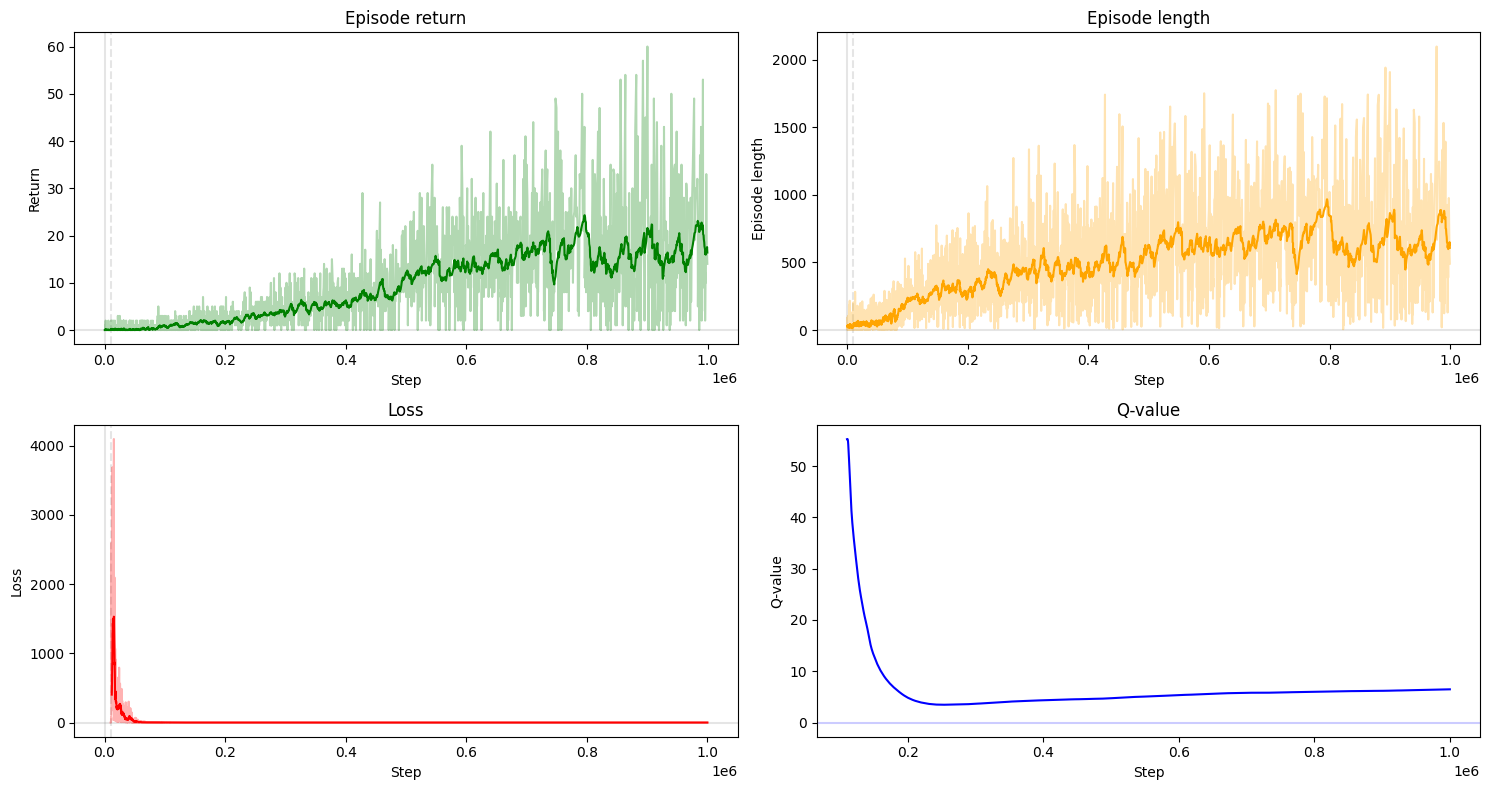

In [32]:
# arr_episode_return, arr_episode_length, arr_loss, arr_q_values = load_history("dqn__MinAtar-Seaquest-v1__1__1748016231")
arr_episode_return, arr_episode_length, arr_loss, arr_q_values = load_history(q.config.run_name)

plot(arr_episode_return, arr_episode_length, arr_loss, arr_q_values)

# Note: MinAtar was designed to train game-playing agents, and there is no human performance score to normalize against. 
# The scores are not directly comparable to Atari scores.

#### Evaluation

Run evaluation episodes 

In [ ]:
%%time 

def evaluate(config):
    env = make_env() 
    
    q = DQN(env, config=config)
    q.load_state_dict(torch.load(f"runs/{config.run_name}.torch", weights_only=True))

    # latents = []
    episode_returns = []
    episode_lengths = []
    
    with torch.no_grad():
        episode = 0
        start_time = time()
        
        obs, _ = env.reset(seed=config.seed)
    
        sprite_location = np.zeros((10, 10), dtype=int)
        
        for global_step in tqdm(range(config.total_eval_timesteps)):
            # Track location for behavior inspection 
            sprite_location += obs[-1,:,:,0].astype(int) 
        
            # Pick action 
            q_values = q(torch.tensor(obs).unsqueeze(0))
            action = torch.argmax(q_values, dim=1).cpu().item()
            
            # Perform environment step
            next_obs, reward, terminated, truncated, info = env.step(action)
            
            # Adopt next observation as new, current observation 
            if terminated or truncated:
                # Next episode
                obs, _ = env.reset()
                episode += 1
                # Record return and episode length for plotting purposes
                if info and "episode" in info: 
                    episode_returns.append(info["episode"]["r"])
                    episode_lengths.append(info["episode"]["l"])
            else:
                # Continue current episode 
                obs = next_obs
                
            # target_max is 0 if the state is terminal 
            if terminated or truncated:
                q_max = torch.zeros(1)
            else:
                q_max, _ = q(torch.tensor(next_obs).unsqueeze(0)).max(dim=1) 
            target = (reward + config.gamma * q_max) 
            pred = q(torch.tensor(obs).unsqueeze(0))[:,action]  # q(s, a)
            loss = F.mse_loss(pred, target)  # squared TD error 
        
        print("Eval episode counter:", episode)
    
        sprite_location = sprite_location/episode
        sprite_location_norm = (sprite_location-sprite_location.min())/(sprite_location.max()-sprite_location.min())

    env.close()

    # Return additional eval data 
    return { 
        "sprite_location_norm": sprite_location_norm,  
        "episode_returns": np.array(episode_returns),
        "episode_lengths": np.array(episode_lengths),
        # "latents": latents
    }

# E.g. evaluate particular run 
eval_data = evaluate(
    Config(
        total_eval_timesteps=100_000, 
        run_name="dqn__MinAtar-Seaquest-v1__1__1748100638"
    )
)

In [ ]:
def plot_stats(data, title=None, color=None):
    plt.figure(figsize=(7, 2.5))
    if title is not None:
        plt.title(title)
    
    x_min = data.mean()-4*data.std()
    x_max = data.mean()+4*data.std()
    
    x = np.linspace(x_min, x_max, 100)
    # Plot corresponding Gaussian 
    y = scipy.stats.norm.pdf(x, loc=data.mean(), scale=data.std())
    
    plt.plot(x, y, color=color)
    plt.xlim(x_min, x_max)
    # sns.kdeplot(data, fill=True)
    plt.axhline(0, color="grey", alpha=0.4, zorder=0)
    plt.axvline(data.mean(), color=color, alpha=0.5, ls="--")
    plt.axvline(0, color="grey", alpha=0.4, ls="--")

    print(pd.Series(data).describe())

In [ ]:
plot_stats(eval_data["episode_returns"], title="Distribution of episode returns")

# Note: MinAtar was designed to train game-playing agents, and there is no human performance score to normalize against. 
# The scores are not directly comparable to Atari scores.

In [ ]:
plot_stats(eval_data["episode_lengths"], title="Distribution of episode lengths", color="orange")

**Behavior inspection**

[[0.  0.1 0.3 0.2 0.1 0.1 0.1 0.  0.  0. ]
 [0.1 0.1 0.4 0.5 1.  0.1 0.1 0.  0.  0. ]
 [0.1 0.1 0.3 0.4 0.4 0.1 0.1 0.1 0.  0. ]
 [0.  0.1 0.3 0.5 0.5 0.3 0.1 0.  0.  0. ]
 [0.  0.1 0.3 0.6 0.8 0.4 0.1 0.  0.  0. ]
 [0.  0.1 0.3 0.5 0.6 0.2 0.1 0.1 0.  0. ]
 [0.1 0.1 0.2 0.4 0.2 0.2 0.1 0.1 0.  0. ]
 [0.  0.1 0.1 0.2 0.1 0.  0.  0.  0.  0. ]
 [0.1 0.1 0.1 0.2 0.2 0.1 0.1 0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]]



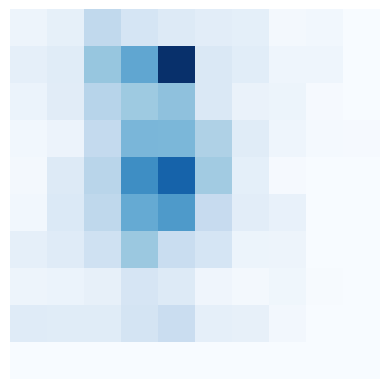

In [70]:
# Too many possible states to inspect at all of them 
# Focus only on aspect of the state: the sprite location 

print(eval_data["sprite_location_norm"].round(1))
print()

plt.axis("off")
plt.imshow(eval_data["sprite_location_norm"], cmap="Blues");

#### Demonstration

In [42]:
def display_state(obs, frame_id, q_values, q_values_history=[], rewards_history=[]):
    # Convert the observation into image
    image = np.amax(obs * np.reshape(np.arange(10)+1, (1, 1, -1)), 2) + 0.5
    # Color    
    cmap = sns.color_palette("cubehelix", 10)
    cmap.insert(0, (0, 0, 0))
    cmap = colors.ListedColormap(cmap)
    bounds = [i for i in range(10+2)]
    norm = colors.BoundaryNorm(bounds, 10+1)
    # Plot 
    fig, ax = plt.subplots(ncols=3, nrows=2, 
                           figsize=(15, 7), width_ratios=[1, 1.2, 1.2], height_ratios=[2.75, 1], 
                           constrained_layout=True)

    # Margins 
    # fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.1, hspace=0.05, wspace=0.05)
    fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.1, hspace=0.1, wspace=0.1)
    
    # Image
    ax[0,0].set_title("MinAtar/SeaQuest")
    ax[0,0].imshow(image, cmap=cmap, norm=norm, interpolation="none")
    ax[0,0].axis("off")
    
    # Q-values
    ax[0,1].set_title(r"Value $\hat{q}(s_t, a_t)$ per step")
    ax[0,1].plot(q_values_history, color="blue", alpha=0.5)
    ax[0,1].xaxis.set_major_locator(MaxNLocator(integer=True))
    # ax[0,1].set_yticks([])
    ax[0,1].set_xlim(0, len(q_values_history)) 
    # Some annoying stuff to make the plot not "jiggle around" whenever a new tick label comes
    #   around that "overflows" to the right of the plot 
    tick_locs = ax[0,1].get_xticks()
    tick_labels = ax[0,1].get_xticklabels()
    new_tick_labels = [label.get_text() if i < len(tick_labels)-1 else "" for i, label in enumerate(tick_labels)]
    ax[0,1].set_xticks(tick_locs)
    ax[0,1].set_xticklabels(new_tick_labels)
    ax[0,1].yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    
    # Rewards
    ax[0,2].set_title(r"Reward $r_t$ per step")
    try:
        markerline, stemlines, baseline = ax[0,2].stem(rewards_history)
        plt.setp(markerline, color="green", markersize=5)
        plt.setp(stemlines, color="green", alpha=0.7)
        plt.setp(baseline, visible=False)
        # plt.setp(baseline, linestyle="-", color="grey", alpha=0.5)
    except ValueError:
        pass 
    ax[0,2].axhline(0, color="grey", alpha=0.5)
    ax[0,2].set_ylim(-0.5, max(7, max(filter(None, [1, *rewards_history]))+1))  
    # ax[0,2].set_yticks([])
    ax[0,2].xaxis.set_major_locator(MaxNLocator(integer=True))
    ax[0,2].set_xlim(0, len(rewards_history))  
    # Some annoying stuff to make the plot not "jiggle around" whenever a new tick label comes
    #   around that "overflows" to the right of the plot 
    tick_locs = ax[0,2].get_xticks()
    tick_labels = ax[0,2].get_xticklabels()
    new_tick_labels = [label.get_text() if i < len(tick_labels)-1 else "" for i, label in enumerate(tick_labels)]
    ax[0,2].set_xticks(tick_locs)
    ax[0,2].set_xticklabels(new_tick_labels)
    # ax[0,2].yaxis.set_major_locator(MaxNLocator(integer=True))

    # Action probs (softmaxed q-values for this state)
    temperature = 0.5
    action_probs = F.softmax(q_values.flatten()/temperature, dim=0).detach()
    ax[1,0].set_title(r"Current values $\hat{q}(s_t, a)$")
    ax[1,0].set_ylim(0, 1)
    ax[1,0].set_yticks([])
    action_names = ["noop", "left", "up", "right", "down", "fire"]
    ax[1,0].bar(action_names, action_probs, color="purple", alpha=0.6, width=0.7)
    highlight_best_action = (action_probs == action_probs.max()) * action_probs.max()  # zero all other actions
    ax[1,0].bar(action_names, highlight_best_action, color="purple", alpha=1.0, width=0.7)

    ax[1,1].set_visible(False)
    ax[1,2].set_visible(False)
    
    # plt.tight_layout()
    if frame_id is not None:
        plt.savefig(f"frames/{frame_id}.png", dpi=200)
    else:
        plt.show()
    plt.close()

Episode ended at t=109
Saving gif


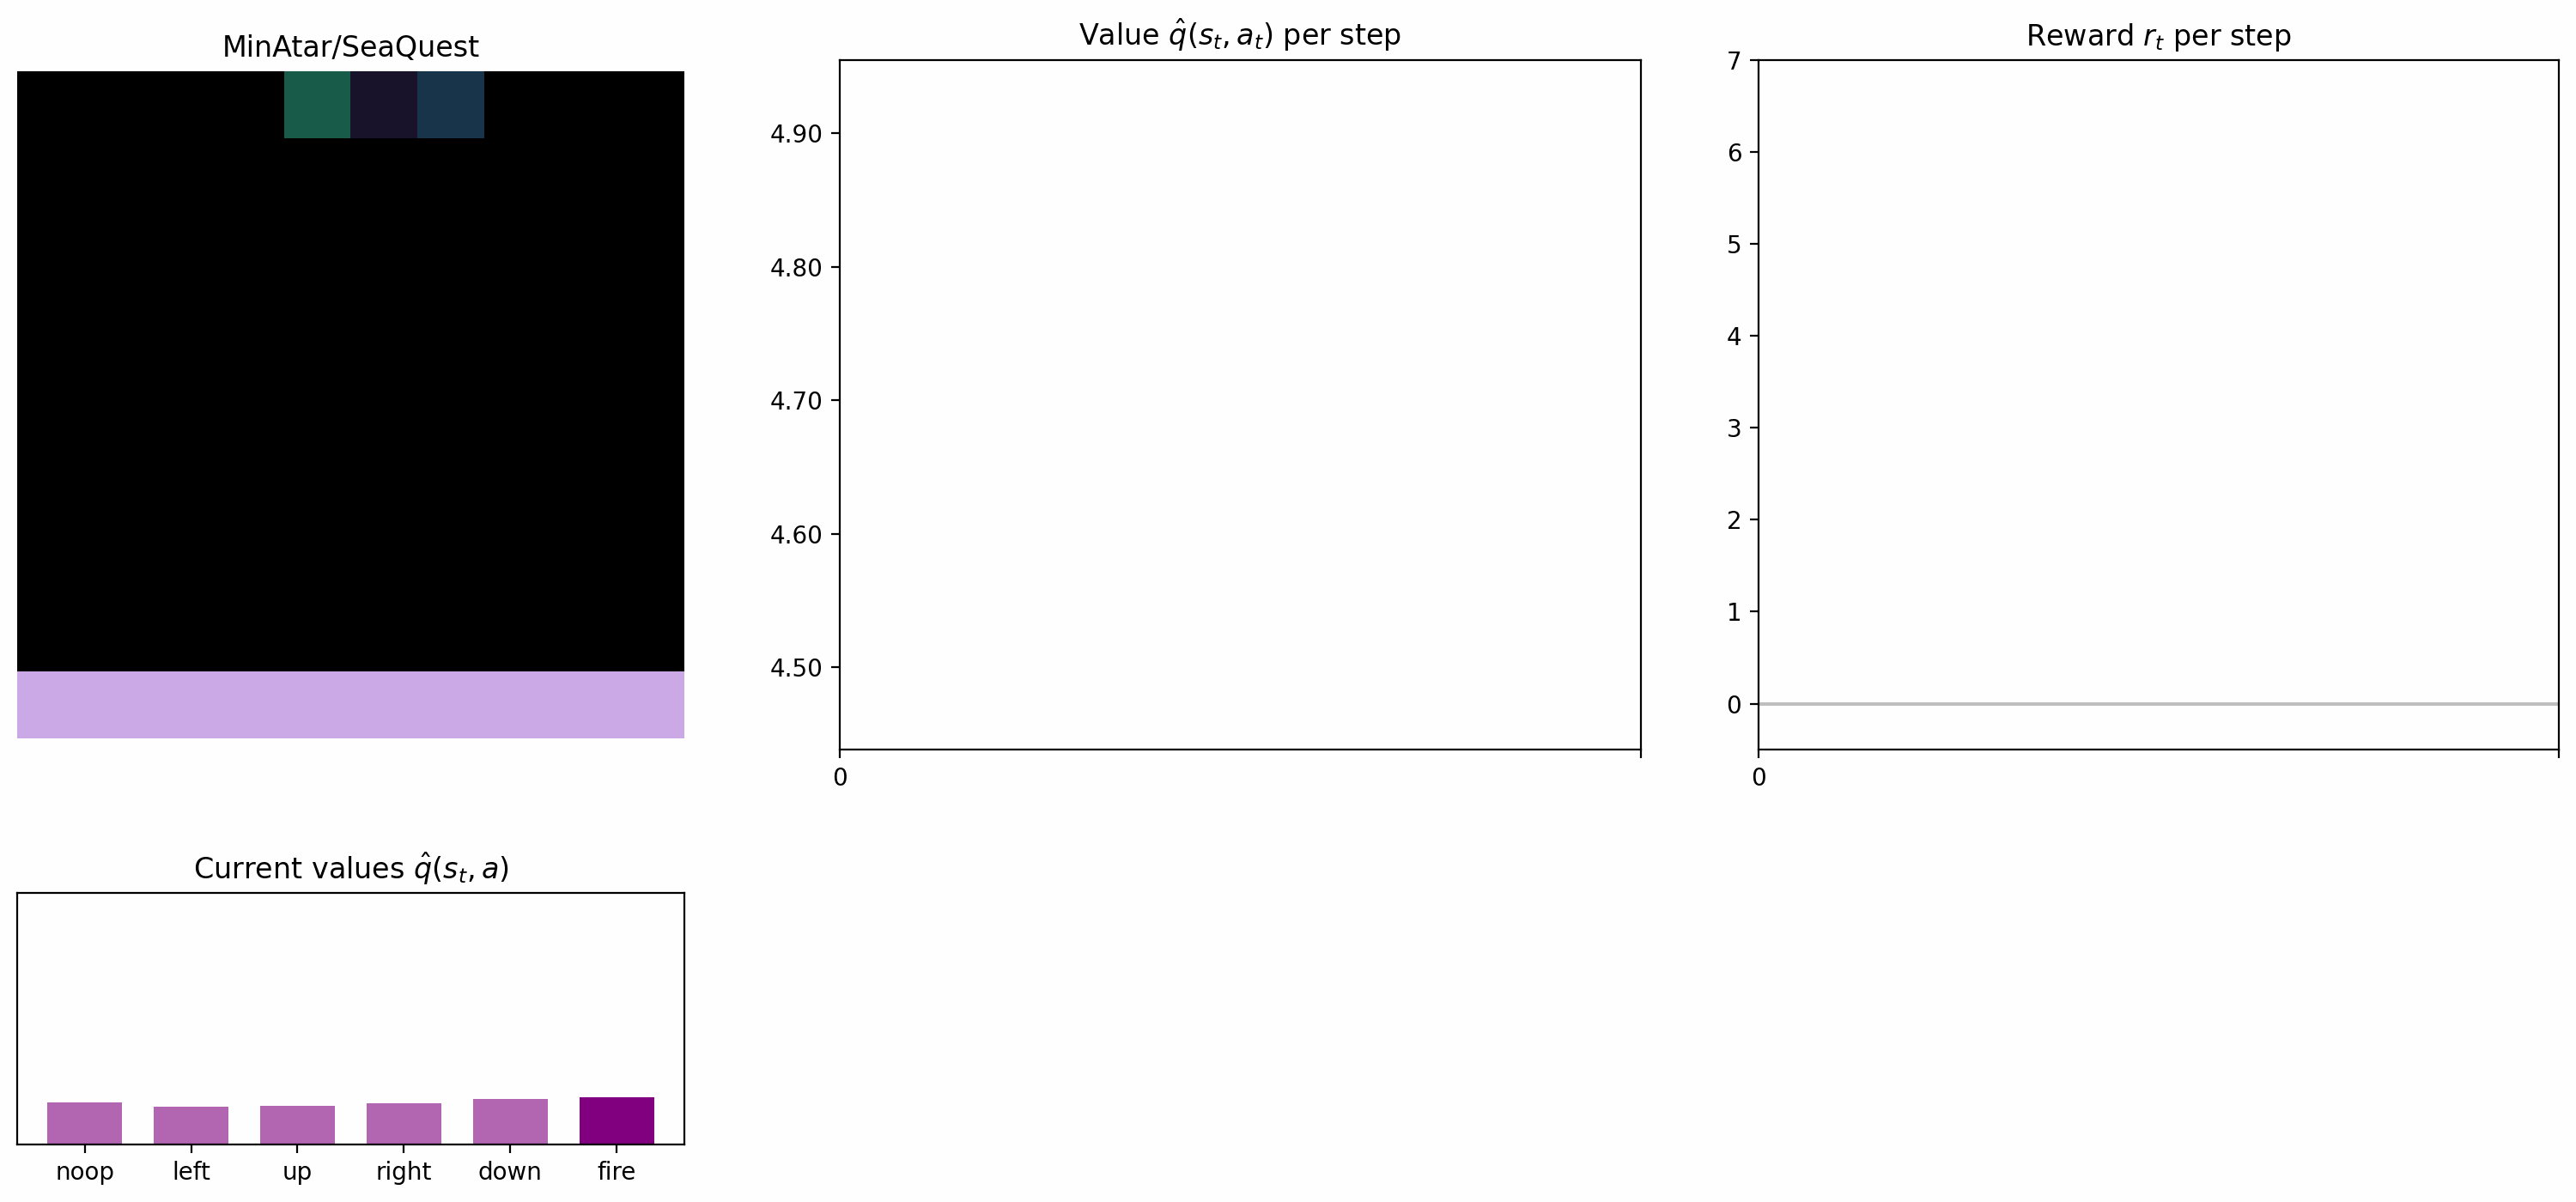

In [45]:
# Delete old frames
for file in os.listdir("frames"):
    if file.endswith(".png"):
        os.remove(f"frames/{file}")

# Run demonstration and save new frames
demo_env = make_env(render_mode="rgb_array")

obs, _ = demo_env.reset();
# display_state(obs[-1], 0)

images = []
demo_q_values_history = []
demo_rewards_history = []
# demo_loss_history = []

n_steps = 110

for t in range(1, n_steps):
    q_values = q(torch.tensor(obs).unsqueeze(0))
    action = torch.argmax(q_values, dim=1).item()
    # action = demo_env.action_space.sample()  # for comparison: uniformly random policy 
    
    obs, reward, terminated, truncated, info = demo_env.step(action) 
    
    demo_q_values_history.append(q_values.max().item())
    demo_rewards_history.append(reward if reward > 0 else None)
    # ...
    
    display_state(obs[-1], 
                  t, # frame id
                  q_values_history=demo_q_values_history,
                  rewards_history=demo_rewards_history,
                  # loss_history=demo_loss_history,
                  q_values=q_values,
                  )
    
    images.append(imageio.v2.imread(f"frames/{t}.png"))
    
    if terminated or truncated or t == n_steps-1:
        print(f"Episode ended at t={t}")
        break 

demo_env.close()

# Save and display gif 
print("Saving gif")
imageio.mimsave(f"{q.config.run_name}.gif", images)
Image(filename=f"{q.config.run_name}.gif", width=1200)